# CPU Baseline — Non-Local Means Denoising

Notebook này xây dựng và đánh giá phiên bản **CPU baseline** của thuật toán
**Non-Local Means (NLM)** dành cho ảnh grayscale.

## Mục tiêu

- Chuẩn bị ảnh sạch và ảnh có Gaussian noise.
- Chạy phiên bản `nlm_cpu_naive`.
- Đo CPU runtime.
- Đánh giá chất lượng khử nhiễu bằng PSNR và SSIM.
- Hiển thị ảnh trước và sau khi khử nhiễu.
- Tạo CPU reference để kiểm tra correctness cho các phiên bản GPU.

Phiên bản CPU này ưu tiên tính rõ ràng và correctness, chưa tập trung vào tối ưu hiệu năng.

## 1. Xác định project root

Notebook có thể được chạy từ thư mục `notebooks/`, trong khi source code nằm trong
thư mục `src/`.

Cell dưới đây:

1. tìm thư mục gốc của project;
2. kiểm tra sự tồn tại của `src`, `kernels` và `pyproject.toml`;
3. thêm project root vào `sys.path`;
4. cho phép notebook import các module từ `src.nlm`.

In [ ]:
from pathlib import Path
import sys


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (
            (path / "src").exists()
            and (path / "kernels").exists()
            and (path / "pyproject.toml").exists()
        ):
            return path

    raise FileNotFoundError(
        "Cannot locate project root."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project root:", PROJECT_ROOT)

Project root: E:\Lap trinh song song ud\gpu_dense_vector_retrieval


## 2. Import thư viện và các module NLM

Các thư viện được sử dụng gồm:

- `time`: đo CPU runtime;
- `matplotlib`: hiển thị ảnh;
- `pandas`: tạo bảng kết quả;
- `NLMConfig`: quản lý cấu hình thí nghiệm;
- `nlm_cpu_naive`: CPU reference implementation;
- `image_utils`: tạo ảnh thử nghiệm và thêm Gaussian noise;
- `evaluate_denoising`: tính các quality metrics.

In [ ]:
import time

import matplotlib.pyplot as plt
import pandas as pd

from src.nlm.config import NLMConfig
from src.nlm.cpu import nlm_cpu_naive
from src.nlm.image_utils import (
    add_gaussian_noise,
    create_camera_test_image,
)
from src.nlm.metrics import evaluate_denoising

## 3. Cấu hình thí nghiệm

Thí nghiệm sử dụng các tham số:

- Kích thước ảnh: `64 × 64`.
- Gaussian noise sigma: `0.08`.
- Patch size: `3 × 3`.
- Search window: `7 × 7`.
- Filtering parameter `h`: `0.12`.
- Random seed: `42`.

Việc sử dụng cùng một `NLMConfig` giúp CPU và các phiên bản GPU chạy với cùng tham số,
từ đó bảo đảm tính công bằng khi so sánh correctness và runtime.

In [ ]:
config = NLMConfig(
    image_size=64,
    noise_sigma=0.08,
    patch_size=3,
    search_window_size=7,
    h=0.12,
    random_seed=42,
)

config.validate()

print(config)

NLMConfig(image_size=64, noise_sigma=0.08, patch_size=3, search_window_size=7, h=0.12, random_seed=42, block_size_x=16, block_size_y=16)


## 4. Chuẩn bị dữ liệu thử nghiệm

Hai ảnh được tạo:

1. `clean_image`: ảnh grayscale sạch dùng làm ground truth;
2. `noisy_image`: ảnh sạch sau khi được thêm Gaussian noise.

Random seed được cố định để noise pattern không thay đổi giữa các lần chạy.
Nhờ đó CPU, GPU V1, GPU V2 và GPU V3 có thể được đánh giá trên cùng một input.

In [ ]:
clean_image = create_camera_test_image(
    config.image_size
)

noisy_image = add_gaussian_noise(
    clean_image,
    sigma=config.noise_sigma,
    seed=config.random_seed,
)

## 5. Chạy CPU baseline

Phiên bản `nlm_cpu_naive` xử lý từng output pixel theo thứ tự tuần tự.

Với mỗi output pixel, CPU thực hiện:

1. lấy reference patch;
2. duyệt toàn bộ candidate patch trong search window;
3. tính mean squared patch distance;
4. chuyển distance thành similarity weight;
5. tính weighted average của các candidate center pixels;
6. ghi kết quả vào output image.

Runtime được đo bằng `time.perf_counter()`.

Đây là CPU baseline dùng để:

- làm reference về correctness;
- tính speedup cho các phiên bản GPU;
- kiểm tra GPU output bằng pixel-wise comparison.

In [ ]:
start = time.perf_counter()

denoised_cpu = nlm_cpu_naive(
    noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
)

cpu_runtime_seconds = (
    time.perf_counter()
    - start
)

cpu_metrics = evaluate_denoising(
    clean_image,
    noisy_image,
    denoised_cpu,
)

print(
    f"CPU runtime: "
    f"{cpu_runtime_seconds:.6f} giây"
)

metrics_table = pd.DataFrame(
    [
        {
            "Implementation": "CPU baseline",
            "Runtime (s)": cpu_runtime_seconds,
            **cpu_metrics,
        }
    ]
)

display(metrics_table)

CPU runtime: 1.986125 s
{'noisy_psnr': 22.21833767309123, 'denoised_psnr': 29.532020074147848, 'denoised_ssim': 0.8383193023493968, 'psnr_improvement': 7.313682401056617}


### Ý nghĩa các quality metrics

- **PSNR**: đo mức độ gần nhau giữa ảnh kết quả và ảnh sạch. PSNR càng cao thì chất lượng tái tạo thường càng tốt.
- **SSIM**: đánh giá mức độ bảo toàn cấu trúc của ảnh. Giá trị càng gần `1` thì hai ảnh càng giống nhau về cấu trúc.
- **Runtime**: tổng thời gian CPU cần để hoàn thành NLM cho toàn bộ ảnh.

CPU runtime ở đây được sử dụng làm mốc `1×` khi tính speedup của GPU V1, GPU V2 và GPU V3.

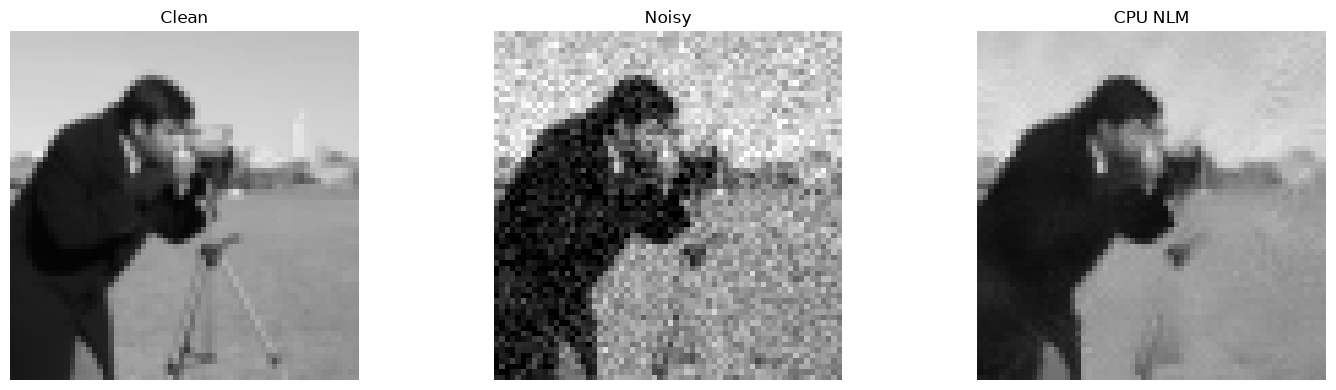

In [ ]:
plt.figure(figsize=(15, 4))

images = [
    ("Clean", clean_image),
    ("Noisy", noisy_image),
    ("CPU NLM", denoised_cpu),
]

for index, (title, image) in enumerate(
    images,
    start=1,
):
    plt.subplot(1, 3, index)
    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()